# 04 Policy Interpretation

## Project Context

This notebook translates the Phase 3 baseline inflation forecast outputs into policy-relevant interpretation and business implications. It is part of the Philippines Macro Nowcasting and Policy Dashboard, a portfolio research project demonstrating an end-to-end macro analytics workflow.

**Disclaimer:** This is a portfolio research project. Nothing in this notebook constitutes an official economic forecast, investment advice, or guidance from the Bangko Sentral ng Pilipinas (BSP), the Philippine Statistics Authority (PSA), or any official institution.

### BSP Inflation Targeting Framework

The BSP uses an inflation targeting framework as its monetary policy approach. Its primary monetary policy objective is price stability. For 2025 to 2028, the BSP's inflation target is **3.0 percent** with a tolerance band of **±1.0 percentage point** (target range: 2.0%–4.0%). The PSA is the official source for CPI and inflation data in the Philippines.

## Policy Interpretation Objectives

This notebook has four objectives:

1. Review the recent Philippines inflation trend relative to the BSP 2025–2028 target band.
2. Summarize Phase 3 model performance for the three baseline models.
3. Interpret the latest April 2026 forecast in the context of the BSP inflation target band.
4. Identify business implications and present three scenario-based analytical paths for policy and market participants.

In [1]:
import os
import warnings
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 100

# Path resolution: nbconvert sets CWD to the notebook directory
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, "src")):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FORECASTS_DIR      = os.path.join(PROJECT_ROOT, "outputs", "forecasts")
SCENARIOS_DIR      = os.path.join(PROJECT_ROOT, "outputs", "scenarios")
FIGURES_DIR        = os.path.join(PROJECT_ROOT, "reports", "figures")

os.makedirs(SCENARIOS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# BSP 2025-2028 inflation target constants
BSP_TARGET_MIDPOINT = 3.0
BSP_TARGET_LOWER    = 2.0
BSP_TARGET_UPPER    = 4.0

print(f"Project root: {PROJECT_ROOT}")
print(f"Scenarios dir: {SCENARIOS_DIR}")
print(f"BSP target band: {BSP_TARGET_LOWER}% – {BSP_TARGET_UPPER}% (midpoint {BSP_TARGET_MIDPOINT}%)")

Project root: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard
Scenarios dir: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/outputs/scenarios
BSP target band: 2.0% – 4.0% (midpoint 3.0%)


## Load Cleaned Indicators and Forecast Outputs

In [2]:
# Load monthly macro indicators
monthly = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "monthly_macro_indicators.csv"))
monthly["date"] = pd.to_datetime(monthly["date"])
monthly = monthly.sort_values("date").reset_index(drop=True)

# Load forecast outputs
latest_forecast = pd.read_csv(os.path.join(FORECASTS_DIR, "latest_inflation_forecast.csv"))
latest_forecast["forecast_origin_date"] = pd.to_datetime(latest_forecast["forecast_origin_date"])
latest_forecast["forecast_target_date"]  = pd.to_datetime(latest_forecast["forecast_target_date"])

forecast_metrics  = pd.read_csv(os.path.join(FORECASTS_DIR, "forecast_metrics.csv"))
test_predictions  = pd.read_csv(os.path.join(FORECASTS_DIR, "inflation_forecast_test_predictions.csv"))
test_predictions["target_date"] = pd.to_datetime(test_predictions["target_date"])

print(f"Monthly rows: {len(monthly)}  |  Date range: {monthly['date'].min().date()} to {monthly['date'].max().date()}")
print(f"Test prediction rows: {len(test_predictions)}")
print(f"\nLatest forecast:")
print(latest_forecast.to_string(index=False))
print(f"\nForecast metrics:")
print(forecast_metrics.to_string(index=False))

Monthly rows: 819  |  Date range: 1958-01-01 to 2026-03-01
Test prediction rows: 163

Latest forecast:
forecast_origin_date forecast_target_date             model           model_backend  latest_observed_inflation_rate  forecast_inflation_rate                                                                                                                                                                  features_used
          2026-03-01           2026-04-01 linear_regression numpy_linear_regression                             4.1                 5.019775 inflation_rate_lag_1, inflation_rate_lag_3, inflation_rate_lag_6, inflation_rate_rolling_3, inflation_rate_rolling_6, inflation_rate_change_1, usd_php_lag_1, usd_php_change_1

Forecast metrics:
            model      mae     rmse      mape  directional_accuracy
linear_regression 0.378536 0.488909 19.126533              0.623288
 naive_last_value 0.382822 0.500184 18.211170              0.000000
moving_average_3m 0.603885 0.756985 28.571

## Inflation Trend Review

The chart below plots the full Philippines headline inflation series from the BSP historical dataset (1958–2026) with the BSP 2025–2028 target band overlaid. The most recent 10 years are highlighted to show the trajectory leading into the current policy period.

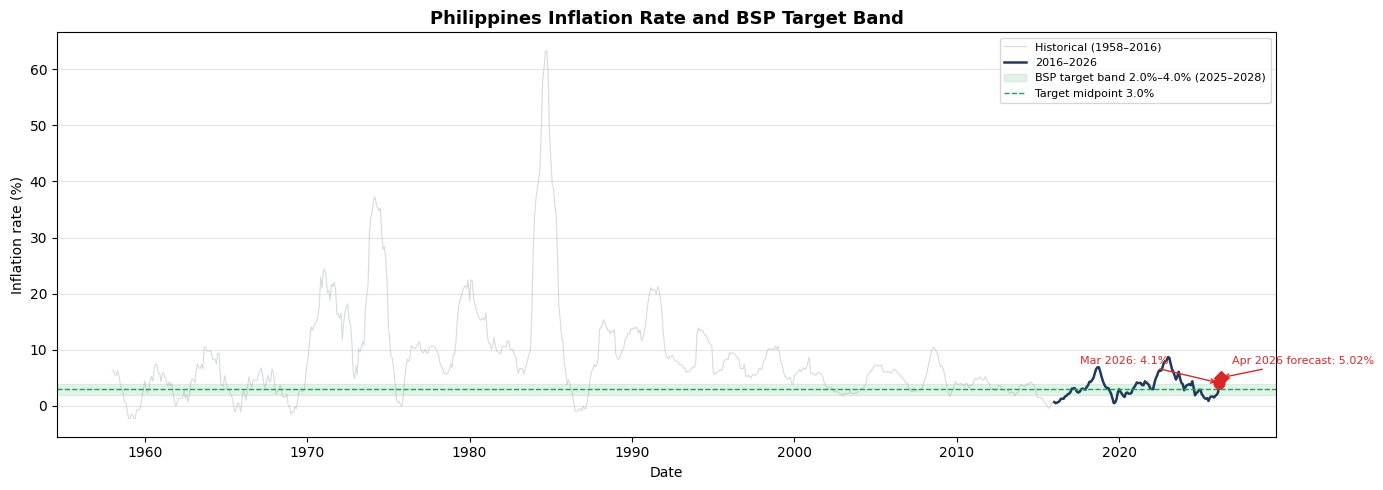

Figure saved: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/reports/figures/inflation_trend_with_bsp_band.png


In [3]:
# Extract key forecast values
row = latest_forecast.iloc[0]
obs_inf   = float(row["latest_observed_inflation_rate"])
fcast_inf = float(row["forecast_inflation_rate"])
obs_date  = row["forecast_origin_date"]
fcast_date = row["forecast_target_date"]

# Filter to rows with valid inflation
valid = monthly[monthly["inflation_rate"].notna()].copy()
recent_cutoff = pd.Timestamp("2016-01-01")
recent = valid[valid["date"] >= recent_cutoff]

fig, ax = plt.subplots(figsize=(14, 5))

# Full historical series
ax.plot(valid["date"], valid["inflation_rate"],
        color="#9ca3af", alpha=0.4, linewidth=0.8, label="Historical (1958–2016)")

# Last 10 years highlighted
ax.plot(recent["date"], recent["inflation_rate"],
        color="#1e3a5f", linewidth=1.8, label="2016–2026")

# BSP target band (2025-2028)
ax.axhspan(BSP_TARGET_LOWER, BSP_TARGET_UPPER,
           alpha=0.12, color="#16a34a", label=f"BSP target band {BSP_TARGET_LOWER}%–{BSP_TARGET_UPPER}% (2025–2028)")
ax.axhline(BSP_TARGET_MIDPOINT, color="#16a34a", linestyle="--",
           linewidth=1.0, label=f"Target midpoint {BSP_TARGET_MIDPOINT}%")

# Latest observed point
ax.scatter([obs_date], [obs_inf], color="#dc2626", zorder=5, s=60)
ax.annotate(f"{obs_date.strftime('%b %Y')}: {obs_inf}%",
            xy=(obs_date, obs_inf), xytext=(-100, 14),
            textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="#dc2626"), color="#dc2626")

# Forecast point
ax.scatter([fcast_date], [fcast_inf], color="#dc2626", marker="D", zorder=5, s=50)
ax.annotate(f"{fcast_date.strftime('%b %Y')} forecast: {fcast_inf:.2f}%",
            xy=(fcast_date, fcast_inf), xytext=(8, 10),
            textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="#dc2626"), color="#dc2626")

ax.set_title("Philippines Inflation Rate and BSP Target Band", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Inflation rate (%)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "inflation_trend_with_bsp_band.png")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Forecast Model Performance Summary

Phase 3 evaluated three models on a chronological 80/20 train/test split of the monthly inflation series:

- **Naive last-value:** Predicts next month's inflation using the current observed value.
- **3-month moving average:** Predicts using the trailing 3-month average.
- **Simple linear regression:** Uses eight features — inflation lags (1, 3, 6 months), rolling averages (3, 6 months), month-over-month change, and USD/PHP lag and change.

The linear regression model outperformed both benchmarks on RMSE and MAE. Note that the naive model shows a lower MAPE than linear regression; this occurs because MAPE is sensitive to the denominator (the observed value) and can favour models that are conservatively biased toward recent values when inflation is low.

            Model    MAE   RMSE   MAPE Directional Accuracy
linear_regression 0.3785 0.4889 19.13%                62.3%
 naive_last_value 0.3828 0.5002 18.21%                 0.0%
moving_average_3m 0.6039 0.7570 28.57%                36.3%


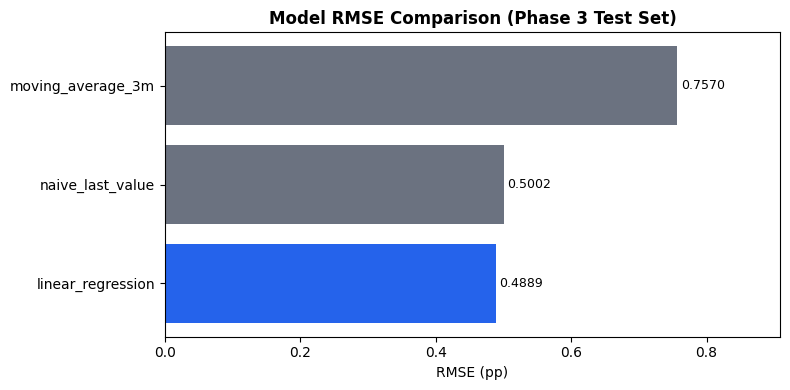

Figure saved: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/reports/figures/phase4_metrics_bar.png


In [4]:
# Format and display metrics table
metrics_display = forecast_metrics.copy()
metrics_display["mae"]  = metrics_display["mae"].round(4)
metrics_display["rmse"] = metrics_display["rmse"].round(4)
metrics_display["mape"] = metrics_display["mape"].round(2).astype(str) + "%"
metrics_display["directional_accuracy"] = (metrics_display["directional_accuracy"] * 100).round(1).astype(str) + "%"
metrics_display.columns = ["Model", "MAE", "RMSE", "MAPE", "Directional Accuracy"]
print(metrics_display.to_string(index=False))

# Bar chart: RMSE by model
rmse_data = forecast_metrics.sort_values("rmse")
colors = ["#2563eb" if m == "linear_regression" else "#6b7280" for m in rmse_data["model"]]

fig2, ax2 = plt.subplots(figsize=(8, 4))
bars = ax2.barh(rmse_data["model"], rmse_data["rmse"], color=colors)
ax2.set_xlabel("RMSE (pp)")
ax2.set_title("Model RMSE Comparison (Phase 3 Test Set)", fontweight="bold")
ax2.axvline(0, color="black", linewidth=0.5)
for bar, val in zip(bars, rmse_data["rmse"]):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)
ax2.set_xlim(0, rmse_data["rmse"].max() * 1.2)
plt.tight_layout()

fig2_path = os.path.join(FIGURES_DIR, "phase4_metrics_bar.png")
plt.savefig(fig2_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig2_path}")

## Latest Forecast Interpretation

The Phase 3 linear regression model forecasts **April 2026 inflation at approximately 5.02%**, up from the March 2026 observed rate of **4.1%**. This represents a forecast acceleration of about **+0.92 percentage points** in one month.

The primary signal driving this forecast is the combination of `inflation_rate_lag_1` (March 2026 inflation of 4.1%, itself a sharp acceleration from prior months) and `inflation_rate_change_1` (the month-over-month change entering March 2026 was approximately +1.7pp). These two features capture the momentum effect that the model extrapolates forward.

**Caveat:** This is a simple baseline model output, not a professional macroeconomic projection. The model does not incorporate BSP policy decisions, rice or oil prices, survey expectations, or fiscal policy inputs.

In [5]:
def classify_vs_band(value, lower, upper):
    if value < lower:
        return "below_band"
    elif value > upper:
        return "above_band"
    else:
        return "within_band"

obs_position  = classify_vs_band(obs_inf,   BSP_TARGET_LOWER, BSP_TARGET_UPPER)
fcast_position = classify_vs_band(fcast_inf, BSP_TARGET_LOWER, BSP_TARGET_UPPER)
deviation_obs   = round(obs_inf   - BSP_TARGET_UPPER, 4)
deviation_fcast = round(fcast_inf - BSP_TARGET_UPPER, 4)

print(f"Observed  ({obs_date.strftime('%Y-%m-%d')}):  {obs_inf}%  → {obs_position}")
print(f"  Deviation from BSP upper bound ({BSP_TARGET_UPPER}%): {deviation_obs:+.4f}pp")
print()
print(f"Forecast  ({fcast_date.strftime('%Y-%m-%d')}): {fcast_inf:.4f}% → {fcast_position}")
print(f"  Deviation from BSP upper bound ({BSP_TARGET_UPPER}%): {deviation_fcast:+.4f}pp")
print()
print(f"Forecast vs observed delta: {fcast_inf - obs_inf:+.4f}pp")

Observed  (2026-03-01):  4.1%  → above_band
  Deviation from BSP upper bound (4.0%): +0.1000pp

Forecast  (2026-04-01): 5.0198% → above_band
  Deviation from BSP upper bound (4.0%): +1.0198pp

Forecast vs observed delta: +0.9198pp


## BSP Inflation Target Band Context

The BSP Monetary Board uses an explicit inflation targeting framework:

- **Primary objective:** Price stability conducive to sustainable economic growth.
- **2025–2028 target:** 3.0 percent, tolerance band ±1.0 percentage point (effective range: 2.0%–4.0%).
- **Data source:** The Philippine Statistics Authority (PSA) publishes official CPI and headline inflation data.

**Observed position (March 2026):** 4.1% — above the upper bound of the target band by 0.1 percentage point.

**Model forecast position (April 2026):** 5.02% — above the upper bound by approximately 1.02 percentage points.

A single month above the band is not unusual and does not automatically trigger policy action. BSP evaluates a range of factors including core inflation, output gap, global conditions, and inflation expectations. However, a sustained trajectory above the band would typically warrant closer BSP monitoring and potentially a tightening bias.

**Note:** This project is a portfolio research project and is not affiliated with or endorsed by the BSP or PSA.

In [6]:
band_summary = pd.DataFrame([{
    "latest_observed_date":       obs_date.strftime("%Y-%m-%d"),
    "latest_observed_inflation":  round(obs_inf, 4),
    "latest_forecast_date":       fcast_date.strftime("%Y-%m-%d"),
    "latest_forecast_inflation":  round(fcast_inf, 4),
    "target_midpoint":            BSP_TARGET_MIDPOINT,
    "target_lower_bound":         BSP_TARGET_LOWER,
    "target_upper_bound":         BSP_TARGET_UPPER,
    "observed_position_vs_target":  obs_position,
    "forecast_position_vs_target":  fcast_position,
}])

band_path = os.path.join(SCENARIOS_DIR, "inflation_target_band_summary.csv")
band_summary.to_csv(band_path, index=False)
print(f"Saved: {band_path}")
print()
print(band_summary.T.to_string(header=False))

Saved: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/outputs/scenarios/inflation_target_band_summary.csv

latest_observed_date         2026-03-01
latest_observed_inflation           4.1
latest_forecast_date         2026-04-01
latest_forecast_inflation        5.0198
target_midpoint                     3.0
target_lower_bound                  2.0
target_upper_bound                  4.0
observed_position_vs_target  above_band
forecast_position_vs_target  above_band


## Scenario-Style Policy Interpretation

The following three scenarios describe analytical paths that could unfold given the current inflation trajectory and model forecast. These are not predictions or BSP guidance — they are structured analytical frames for understanding potential outcomes and their implications.

---

**Scenario A — BSP holds or tightens (elevated inflation persists)**
If headline inflation remains above 4.0% into Q2 2026, the BSP is likely to maintain its current policy rate or shift to a tightening bias. This environment would support NIM expansion for deposit-funded banks but raise borrowing costs for corporates and consumers.

**Scenario B — BSP eases (inflation reverses toward target)**
If inflation decelerates sharply back toward the 3.0% midpoint — driven by lower rice prices, peso appreciation, or demand slowdown — the BSP may resume its easing cycle. This would lower lending rates and create a favorable refinancing window for corporates.

**Scenario C — External shock amplifies inflation (FX or commodity)**
If the peso depreciates significantly or global commodity prices spike, imported inflation could amplify upside risks beyond the model forecast. Corporates with USD-denominated exposure would face simultaneous rate and FX pressure.

In [7]:
policy_rows = [
    {
        "section":    "inflation_trend",
        "finding":    "March 2026 headline inflation at 4.1%, above the BSP 4.0% upper bound by 0.1pp",
        "implication": "BSP is likely in a monitoring posture; no clear easing signal from recent inflation data",
        "caveat":     "Single-month breach; trend trajectory and core inflation matter more than a one-month reading",
    },
    {
        "section":    "model_performance",
        "finding":    "Linear regression RMSE 0.4889, directional accuracy 62.3% on 20% chronological holdout",
        "implication": "Model captures modest directional signal beyond the naive benchmark (0% directional accuracy)",
        "caveat":     "MAPE 19.1% implies meaningful absolute forecast uncertainty; not a production nowcasting model",
    },
    {
        "section":    "latest_forecast",
        "finding":    "April 2026 model forecast: 5.02%, above the BSP upper bound by approximately 1.02pp",
        "implication": "Forecast implies continued upside inflation pressure if March momentum persists into April",
        "caveat":     "Model uses only lagged inflation and USD/PHP features; no commodity, rice, or policy-rate inputs",
    },
    {
        "section":    "scenario_a_bsp_hold_tighten",
        "finding":    "If inflation remains above 4.0% into Q2 2026, BSP may hold current policy rate or tighten",
        "implication": "Higher borrowing costs; short-term NIM support for banks; loan repricing risk for fintechs",
        "caveat":     "BSP decisions depend on full macro picture including core inflation, output gap, and global conditions",
    },
    {
        "section":    "scenario_b_bsp_ease",
        "finding":    "If inflation reverses quickly toward 3.0%, BSP may resume its easing cycle",
        "implication": "Lower lending rates; favorable refinancing environment for corporates",
        "caveat":     "Easing cycle requires sustained disinflation, not a single favorable data point",
    },
    {
        "section":    "scenario_c_external_shock",
        "finding":    "Peso depreciation or commodity price spike could amplify inflation beyond the model forecast",
        "implication": "Corporates with USD-denominated debt face simultaneous rate and FX pressure",
        "caveat":     "External shocks are not modeled; USD/PHP feature in the model provides only a partial FX channel",
    },
    {
        "section":    "business_banks",
        "finding":    "Elevated inflation sustaining BSP at current rate supports short-term NIM expansion",
        "implication": "Variable-rate loan books benefit; fixed-rate funding creates repricing risk on the liability side",
        "caveat":     "Asset quality monitoring becomes more important as higher prices compress household debt service capacity",
    },
    {
        "section":    "business_fintechs",
        "finding":    "Consumer fintech lenders face higher funding costs and potential delinquency uptick",
        "implication": "Loan repricing windows are shorter for fintech products; scenario analysis on cost-of-funds is prudent",
        "caveat":     "Impact depends heavily on borrower credit quality, loan tenor, and fintech funding structure",
    },
    {
        "section":    "business_corporate",
        "finding":    "Cost of debt rises in sustained above-band inflation; USD/PHP at 59.4 adds import cost pressure",
        "implication": "CFOs should stress-test refinancing assumptions against 4.5%–5.5% inflation scenarios for H1 2026",
        "caveat":     "Scenario is model-generated, not a professional forecast; actual BSP path and inflation trajectory are unknown",
    },
]

policy_df = pd.DataFrame(policy_rows)
policy_path = os.path.join(SCENARIOS_DIR, "policy_interpretation_summary.csv")
policy_df.to_csv(policy_path, index=False)
print(f"Saved {len(policy_df)} rows to: {policy_path}")
policy_df

Saved 9 rows to: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/outputs/scenarios/policy_interpretation_summary.csv


,section,finding,implication,caveat
0,inflation_trend,"March 2026 headline inflation at 4.1%, above t...",BSP is likely in a monitoring posture; no clea...,Single-month breach; trend trajectory and core...
1,model_performance,"Linear regression RMSE 0.4889, directional acc...",Model captures modest directional signal beyon...,MAPE 19.1% implies meaningful absolute forecas...
2,latest_forecast,"April 2026 model forecast: 5.02%, above the BS...",Forecast implies continued upside inflation pr...,Model uses only lagged inflation and USD/PHP f...
3,scenario_a_bsp_hold_tighten,"If inflation remains above 4.0% into Q2 2026, ...",Higher borrowing costs; short-term NIM support...,BSP decisions depend on full macro picture inc...
4,scenario_b_bsp_ease,"If inflation reverses quickly toward 3.0%, BSP...",Lower lending rates; favorable refinancing env...,"Easing cycle requires sustained disinflation, ..."
5,scenario_c_external_shock,Peso depreciation or commodity price spike cou...,Corporates with USD-denominated debt face simu...,External shocks are not modeled; USD/PHP featu...
6,business_banks,Elevated inflation sustaining BSP at current r...,Variable-rate loan books benefit; fixed-rate f...,Asset quality monitoring becomes more importan...
7,business_fintechs,Consumer fintech lenders face higher funding c...,Loan repricing windows are shorter for fintech...,Impact depends heavily on borrower credit qual...
8,business_corporate,Cost of debt rises in sustained above-band inf...,CFOs should stress-test refinancing assumption...,"Scenario is model-generated, not a professiona..."


## Business Relevance

### Banks

- Elevated inflation sustaining BSP at its current policy rate supports short-term net interest margin (NIM) expansion for deposit-funded lenders, as short-term rates remain elevated.
- If BSP tightens, variable-rate loan books benefit from higher yields, but fixed-rate liabilities create repricing risk on the funding side.
- Credit quality monitoring becomes more important as higher consumer prices compress household disposable income and debt service capacity, particularly for consumer and MSME loan segments.

### Fintechs

- Consumer-facing fintech lenders face dual pressure: rising funding costs from the higher-rate environment and a potential uptick in delinquency among price-sensitive borrowers.
- Loan repricing windows are shorter for digital lending products; scenario analysis on cost-of-funds assumptions under 4.5%–5.5% inflation is prudent for H1 2026 planning.
- Fintechs with foreign-currency funding exposure also face peso depreciation risk under Scenario C.

### Corporate Finance

- Corporates refinancing peso-denominated debt in a sustained above-band inflation environment should model borrowing costs at 100–150 basis points above recent low-rate expectations.
- The March 2026 USD/PHP rate of approximately 59.4 adds imported cost pressure for businesses with significant USD-denominated inputs or payables.
- Working capital planning should incorporate 4.5%–5.5% inflation sensitivity scenarios for Q2–Q3 2026, with downside scenario modeled at a return toward the 3.0% target mid-year.

## Limitations

- The Phase 3 model is a simple linear regression baseline trained on monthly historical Philippines inflation and USD/PHP exchange rate data. It does not include rice prices, oil prices, core inflation, BSP policy rate, survey expectations, fiscal variables, or global macro indicators.
- The test MAPE of 19.1% implies typical absolute forecast errors that may be material in a policy or business decision context.
- Directional accuracy of 62.3% is above the naive benchmark (0%) but is not reliable for calling turning points. The model will miss sharp reversals.
- The chronological 80/20 split does not simulate real-time rolling-origin forecasting. Reported metrics likely overstate out-of-sample performance in a live production setting.
- The NumPy least-squares fallback was used during Phase 3 execution due to a local NumPy/sklearn compatibility issue. Results are mathematically equivalent but the model is not a sklearn estimator.
- **This is a portfolio research project.** Nothing in this notebook constitutes official economic analysis, investment advice, or BSP guidance. All interpretations are analytical only and should not be used as the basis for financial or policy decisions.

## Dashboard-Ready Narrative Outputs

The code cell below saves `dashboard_policy_notes.md` to `outputs/scenarios/`. This file contains five pre-authored text blocks that the Phase 5 Streamlit dashboard can consume directly, avoiding the need to recompute narratives in the app layer.

In [8]:
# Compute dynamic context for narrative blocks
recent_12m = valid.tail(12)
recent_min  = round(recent_12m["inflation_rate"].min(), 2)
recent_max  = round(recent_12m["inflation_rate"].max(), 2)
recent_avg  = round(recent_12m["inflation_rate"].mean(), 2)

obs_date_str   = obs_date.strftime("%B %Y")
fcast_date_str = fcast_date.strftime("%B %Y")
fcast_rounded  = round(fcast_inf, 2)
rmse_val = forecast_metrics.loc[forecast_metrics["model"] == "linear_regression", "rmse"].values[0]
mape_val = forecast_metrics.loc[forecast_metrics["model"] == "linear_regression", "mape"].values[0]

notes = f"""# Dashboard Policy Notes
## Generated: {pd.Timestamp.now().strftime('%Y-%m-%d')}
## Source: notebooks/04_policy_interpretation.ipynb
## Disclaimer: Portfolio research project. Not an official BSP or institutional forecast.

---

## inflation_context
Headline inflation in the Philippines reached {obs_inf}% in {obs_date_str},
above the BSP target band upper bound of {BSP_TARGET_UPPER}% by {round(obs_inf - BSP_TARGET_UPPER, 2)}pp.
Over the prior 12 months, inflation ranged from {recent_min}% to {recent_max}%,
with an average of {recent_avg}%.
The sharp acceleration entering March 2026 was the primary signal entering the forecast model.

---

## forecast_context
The Phase 3 linear regression model forecasts {fcast_date_str} inflation
at approximately {fcast_rounded}%.
This is {round(fcast_inf - BSP_TARGET_UPPER, 2)}pp above the BSP target band upper bound of {BSP_TARGET_UPPER}%.
The forecast reflects momentum from lagged inflation and USD/PHP exchange rate inputs.
Model test error (RMSE: {round(rmse_val, 4)}) implies the actual outcome could plausibly
range from roughly {round(fcast_rounded - rmse_val, 2)}% to {round(fcast_rounded + rmse_val, 2)}%.

---

## policy_target_context
The BSP Monetary Board uses an inflation targeting framework.
The 2025-2028 inflation target is {BSP_TARGET_MIDPOINT}% +/-1.0pp
(band: {BSP_TARGET_LOWER}%–{BSP_TARGET_UPPER}%).
With both the {obs_date_str} observation ({obs_inf}%) and the {fcast_date_str}
model forecast ({fcast_rounded}%) above the band, the BSP is likely in a monitoring
posture. A sustained above-band trajectory would signal potential holds or tightening
bias; rapid disinflation would support resumption of easing.

---

## business_relevance
Elevated inflation has direct implications for financial sector participants.
Banks may see short-term NIM support if BSP holds policy rate, but face credit
quality risk as higher prices pressure household debt service capacity.
Fintechs should stress-test funding cost assumptions and monitor early delinquency signals.
Corporates with peso debt exposure or import-dependent cost structures should model
borrowing and working-capital scenarios at {round(fcast_rounded, 1)}%–{round(fcast_rounded + 0.5, 1)}%
inflation for H1 2026.

---

## limitations
This dashboard is a portfolio research project. Forecasts are generated by a simple
linear regression model trained on historical Philippines inflation and USD/PHP data.
The model does not incorporate BSP policy rate decisions, rice or oil price inputs,
survey expectations, or fiscal variables. Model MAPE is {round(mape_val, 1)}% on the test set.
Nothing in this dashboard constitutes official economic analysis, investment advice,
or guidance from BSP, PSA, or any official institution.
"""

notes_path = os.path.join(SCENARIOS_DIR, "dashboard_policy_notes.md")
with open(notes_path, "w") as f:
    f.write(notes)
print(f"Saved: {notes_path} ({len(notes)} characters)")

Saved: /Users/rovs/Documents/New project 2/projects/philippines-macro-nowcasting-dashboard/outputs/scenarios/dashboard_policy_notes.md (2347 characters)


In [9]:
# Verify all output files
output_files = [
    os.path.join(SCENARIOS_DIR, "inflation_target_band_summary.csv"),
    os.path.join(SCENARIOS_DIR, "policy_interpretation_summary.csv"),
    os.path.join(SCENARIOS_DIR, "dashboard_policy_notes.md"),
    os.path.join(FIGURES_DIR,   "inflation_trend_with_bsp_band.png"),
    os.path.join(FIGURES_DIR,   "phase4_metrics_bar.png"),
]

print("Phase 4 output verification:")
print("-" * 70)
all_ok = True
for path in output_files:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = "OK" if (exists and size > 0) else "MISSING OR EMPTY"
    if status != "OK":
        all_ok = False
    rel = os.path.relpath(path, PROJECT_ROOT)
    print(f"  {status:<20} {size:>8} bytes  {rel}")

print("-" * 70)
print("All outputs verified OK." if all_ok else "WARNING: one or more outputs are missing or empty.")

Phase 4 output verification:
----------------------------------------------------------------------
  OK                        271 bytes  outputs/scenarios/inflation_target_band_summary.csv
  OK                       2691 bytes  outputs/scenarios/policy_interpretation_summary.csv
  OK                       2351 bytes  outputs/scenarios/dashboard_policy_notes.md
  OK                      66229 bytes  reports/figures/inflation_trend_with_bsp_band.png
  OK                      17854 bytes  reports/figures/phase4_metrics_bar.png
----------------------------------------------------------------------
All outputs verified OK.


## Next Steps for Phase 5 Dashboard

Phase 5 will build a Streamlit dashboard in `dashboard/app.py`. The dashboard will be built on top of the pre-computed outputs from Phases 3 and 4 — no model retraining happens in the app.

**Key dashboard inputs:**
- `data/processed/monthly_macro_indicators.csv` — inflation trend chart
- `outputs/forecasts/latest_inflation_forecast.csv` — latest forecast indicator card
- `outputs/scenarios/inflation_target_band_summary.csv` — BSP band position badge
- `outputs/scenarios/policy_interpretation_summary.csv` — scenario interpretation table
- `outputs/scenarios/dashboard_policy_notes.md` — pre-authored narrative text blocks

**Planned dashboard panels:**
1. Inflation trend chart with BSP target band overlay
2. Latest forecast indicator card (observed vs forecast)
3. BSP band position badge (above/within/below)
4. Scenario interpretation summary table
5. Limitations disclaimer panel

**Design principle:** The Streamlit app should read and display pre-computed outputs. Business narrative text should be sourced from `dashboard_policy_notes.md` rather than hardcoded in the app layer, so the narrative can be updated by re-executing this notebook without modifying the app code.